In [1]:
import numpy as np
import joblib
import os
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score

# Load raw data
train_df = pd.read_csv('../data/raw/train.csv')
val_df = pd.read_csv('../data/raw/val.csv')

#  text combine
train_texts = (train_df['article'] + ' ' + train_df['question']).tolist()
val_texts = (val_df['article'] + ' ' + val_df['question']).tolist()

train_labels = train_df['answer'].tolist()
val_labels = val_df['answer'].tolist()

# TF-IDF 
print("Vectorizing...")
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', sublinear_tf=True)
X_train = tfidf.fit_transform(train_texts)
X_val = tfidf.transform(val_texts)

print("Training LR...")
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train, train_labels)
lr_pred = lr.predict(X_val)
print(f"LR Accuracy: {accuracy_score(val_labels, lr_pred):.4f}")
print(f"LR F1: {f1_score(val_labels, lr_pred, average='macro'):.4f}")

print("\nTraining SVM...")
svm = LinearSVC(max_iter=200, random_state=42)
svm.fit(X_train, train_labels)
svm_pred = svm.predict(X_val)
print(f"SVM Accuracy: {accuracy_score(val_labels, svm_pred):.4f}")
print(f"SVM F1: {f1_score(val_labels, svm_pred, average='macro'):.4f}")

os.makedirs('../models/model_a/traditional', exist_ok=True)
joblib.dump(lr, '../models/model_a/traditional/logistic_regression.pkl')
joblib.dump(svm, '../models/model_a/traditional/svm.pkl')
joblib.dump(tfidf, '../models/model_a/traditional/tfidf_vectorizer.pkl')
print("\nSaved!")

Vectorizing...
Training LR...
LR Accuracy: 0.2648
LR F1: 0.2444

Training SVM...
SVM Accuracy: 0.2660
SVM F1: 0.2459

Saved!


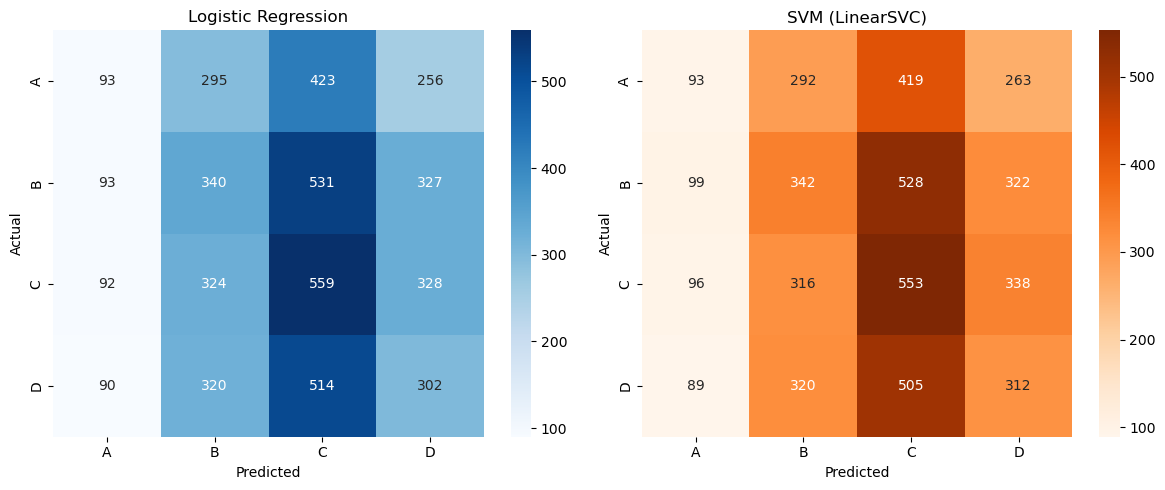

Saved!


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LR Confusion Matrix
cm_lr = confusion_matrix(val_labels, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A','B','C','D'],
            yticklabels=['A','B','C','D'], ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# SVM Confusion Matrix
cm_svm = confusion_matrix(val_labels, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['A','B','C','D'],
            yticklabels=['A','B','C','D'], ax=axes[1])
axes[1].set_title('SVM (LinearSVC)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../models/model_a/traditional/confusion_matrices.png')
plt.show()
print("Saved!")

In [3]:
import subprocess
import os

os.chdir('C:/Users/mudas/race_rc_project')

result1 = subprocess.run(['git', 'add', 'src/model_a_train.py', 'notebooks/model_a_training.ipynb', 'models/'], capture_output=True, text=True)
result2 = subprocess.run(['git', 'commit', '-m', 'add Model A traditional ML'], capture_output=True, text=True)
result3 = subprocess.run(['git', 'push'], capture_output=True, text=True)

print(result2.stdout)
print(result3.stdout)
print(result3.stderr)

[main 71ea194] add Model A traditional ML
 8 files changed, 236 insertions(+)
 create mode 100644 models/model_a/traditional/Logistic_Regression_confusion_matrix.png
 create mode 100644 models/model_a/traditional/SVM_confusion_matrix.png
 create mode 100644 models/model_a/traditional/confusion_matrices.png
 create mode 100644 models/model_a/traditional/logistic_regression.pkl
 create mode 100644 models/model_a/traditional/svm.pkl
 create mode 100644 models/model_a/traditional/tfidf_vectorizer.pkl
 create mode 100644 notebooks/model_a_training.ipynb


To https://github.com/mudassirs52/race_rc_project.git
   f862468..71ea194  main -> main



In [5]:
import os
os.makedirs('../models/model_a/traditional', exist_ok=True)
print("Done!")

Done!


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

print("Training K-Means...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_train)

train_clusters = kmeans.predict(X_train)
val_clusters = kmeans.predict(X_val)

# Silhouette Score
sil_score = silhouette_score(X_val, val_clusters, sample_size=500)
print(f"Silhouette Score: {sil_score:.4f}")

# Purity Score
def purity_score(y_true, y_pred):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)

# Labels encode karo
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
val_labels_encoded = le.fit_transform(val_labels)

purity = purity_score(val_labels_encoded, val_clusters)
print(f"Purity Score: {purity:.4f}")

joblib.dump(kmeans, '../models/model_a/traditional/kmeans.pkl')
print("K-Means Saved!")

Training K-Means...
Silhouette Score: 0.0095
Purity Score: 0.2697
K-Means Saved!


Plotting K-Means clusters...


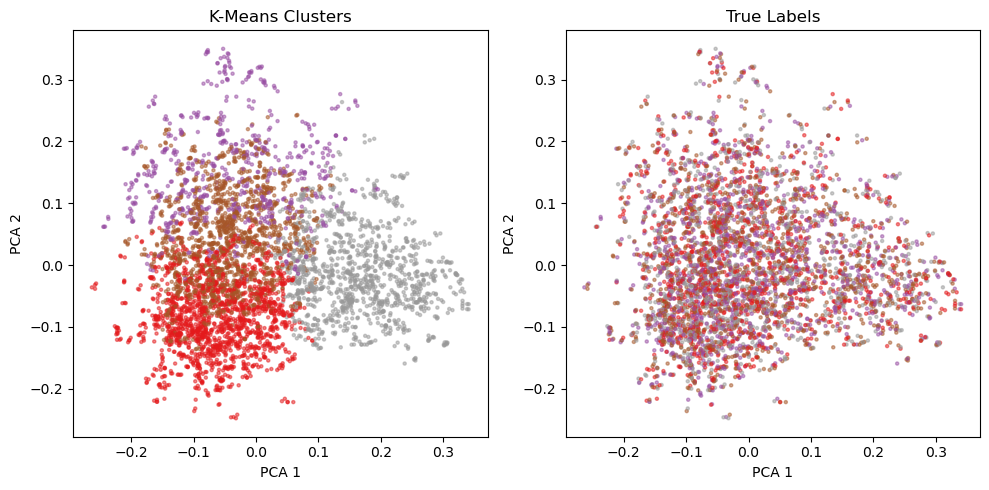

Saved!


In [7]:
from sklearn.decomposition import PCA

print("Plotting K-Means clusters...")
pca = PCA(n_components=2, random_state=42)
X_val_2d = pca.fit_transform(X_val.toarray())

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_val_2d[:, 0], X_val_2d[:, 1], c=val_clusters, cmap='Set1', alpha=0.5, s=5)
plt.title('K-Means Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.subplot(1, 2, 2)
plt.scatter(X_val_2d[:, 0], X_val_2d[:, 1], c=val_labels_encoded, cmap='Set1', alpha=0.5, s=5)
plt.title('True Labels')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.tight_layout()
plt.savefig('../models/model_a/traditional/kmeans_clusters.png')
plt.show()
print("Saved!")

In [9]:
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import accuracy_score, f1_score

print("Training Label Propagation...")

# Sirf 2000 samples
X_train_small = X_train[:2000].toarray()
X_val_dense = X_val.toarray()

train_labels_encoded = le.transform(train_labels)
masked_labels = train_labels_encoded[:2000].copy()

np.random.seed(42)
mask = np.random.rand(len(masked_labels)) < 0.8
masked_labels[mask] = -1

print(f"Labeled: {np.sum(masked_labels != -1)}")
print(f"Unlabeled: {np.sum(masked_labels == -1)}")

lp = LabelPropagation(max_iter=50, n_neighbors=5, kernel='knn')
lp.fit(X_train_small, masked_labels)

lp_pred = lp.predict(X_val_dense)
val_labels_encoded = le.transform(val_labels)
lp_acc = accuracy_score(val_labels_encoded, lp_pred)
lp_f1 = f1_score(val_labels_encoded, lp_pred, average='macro')

print(f"\nLabel Propagation Accuracy: {lp_acc:.4f}")
print(f"Label Propagation F1: {lp_f1:.4f}")

joblib.dump(lp, '../models/model_a/traditional/label_propagation.pkl')
print("Saved!")

Training Label Propagation...
Labeled: 403
Unlabeled: 1597


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:324: ConvergenceWarning: max_iter=50 was reached without convergence.
  warnings.warn(



Label Propagation Accuracy: 0.2519
Label Propagation F1: 0.2515
Saved!


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


In [10]:
print("\n=== Full Model Comparison ===")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Type':>15}")
print("-" * 65)
print(f"{'Logistic Regression':<25} {accuracy_score(val_labels, lr_pred):>10.4f} {f1_score(val_labels, lr_pred, average='macro'):>10.4f} {'Supervised':>15}")
print(f"{'SVM (LinearSVC)':<25} {accuracy_score(val_labels, svm_pred):>10.4f} {f1_score(val_labels, svm_pred, average='macro'):>10.4f} {'Supervised':>15}")
print(f"{'K-Means':<25} {'N/A':>10} {purity:>10.4f} {'Unsupervised':>15}")
print(f"{'Label Propagation':<25} {lp_acc:>10.4f} {lp_f1:>10.4f} {'Semi-Supervised':>15}")


=== Full Model Comparison ===
Model                       Accuracy   Macro F1            Type
-----------------------------------------------------------------
Logistic Regression           0.2648     0.2444      Supervised
SVM (LinearSVC)               0.2660     0.2459      Supervised
K-Means                          N/A     0.2697    Unsupervised
Label Propagation             0.2519     0.2515 Semi-Supervised


In [11]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score

print("Training Ensemble...")

# LinearSVC probability ke liye calibrate karna hoga
calibrated_svm = CalibratedClassifierCV(LinearSVC(max_iter=200, random_state=42))

# Soft Voting Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=200, random_state=42)),
        ('svm', calibrated_svm)
    ],
    voting='soft'
)

ensemble.fit(X_train, train_labels)
ensemble_pred = ensemble.predict(X_val)

ens_acc = accuracy_score(val_labels, ensemble_pred)
ens_f1 = f1_score(val_labels, ensemble_pred, average='macro')

print(f"Ensemble Accuracy: {ens_acc:.4f}")
print(f"Ensemble F1: {ens_f1:.4f}")

joblib.dump(ensemble, '../models/model_a/traditional/ensemble.pkl')
print("Ensemble Saved!")

# Final comparison
print("\n=== Final Comparison ===")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 47)
print(f"{'Logistic Regression':<25} {accuracy_score(val_labels, lr_pred):>10.4f} {f1_score(val_labels, lr_pred, average='macro'):>10.4f}")
print(f"{'SVM':<25} {accuracy_score(val_labels, svm_pred):>10.4f} {f1_score(val_labels, svm_pred, average='macro'):>10.4f}")
print(f"{'Ensemble':<25} {ens_acc:>10.4f} {ens_f1:>10.4f}")

Training Ensemble...
Ensemble Accuracy: 0.2709
Ensemble F1: 0.2290
Ensemble Saved!

=== Final Comparison ===
Model                       Accuracy   Macro F1
-----------------------------------------------
Logistic Regression           0.2648     0.2444
SVM                           0.2660     0.2459
Ensemble                      0.2709     0.2290


In [19]:
import subprocess
import os

os.chdir('C:/Users/mudas/race_rc_project')

subprocess.run(['git', 'init'])
subprocess.run(['git', 'add', '.'])
subprocess.run(['git', 'commit', '-m', 'initial commit clean'])
subprocess.run(['git', 'branch', '-M', 'main'])
subprocess.run(['git', 'remote', 'add', 'origin', 'https://github.com/mudassirs52/race_rc_project.git'])
result = subprocess.run(['git', 'push', '-u', 'origin', 'main', '--force'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

branch 'main' set up to track 'origin/main'.

To https://github.com/mudassirs52/race_rc_project.git
   09ec0e6..5bbb76f  main -> main



In [2]:
import subprocess
subprocess.run(['pip', 'install', 'rouge-score', 'nltk', '--user'])

CompletedProcess(args=['pip', 'install', 'rouge-score', 'nltk', '--user'], returncode=0)

In [3]:
import subprocess
subprocess.run(['pip', 'install', 'evaluate', '--user'])

CompletedProcess(args=['pip', 'install', 'evaluate', '--user'], returncode=0)

In [5]:
import nltk
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
print("Done!")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mudas\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mudas\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mudas\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Done!


In [8]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

# Data load karo
train_df = pd.read_csv('../data/raw/train.csv')
val_df = pd.read_csv('../data/raw/dev.csv')

train_texts = (train_df['article'] + ' ' + train_df['question']).tolist()
val_texts = (val_df['article'] + ' ' + val_df['question']).tolist()

train_labels = train_df['answer'].tolist()
val_labels = val_df['answer'].tolist()

# TF-IDF
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', sublinear_tf=True)
X_train = tfidf.fit_transform(train_texts)
X_val = tfidf.transform(val_texts)

# Models train karo
print("Training LR...")
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train, train_labels)

print("Training SVM...")
svm = LinearSVC(max_iter=200, random_state=42)
svm.fit(X_train, train_labels)

print("Done!")

Training LR...
Training SVM...
Done!


In [9]:
import pandas as pd
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import numpy as np

# Val data
references = val_labels[:500]
predictions_lr = lr.predict(X_val[:500])
predictions_svm = svm.predict(X_val[:500])

# BLEU, ROUGE, METEOR calculate karo
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def evaluate_metrics(references, predictions):
    bleu_scores = []
    rouge1_scores = []
    rougeL_scores = []
    meteor_scores = []

    for ref, pred in zip(references, predictions):
        bleu = sentence_bleu([list(ref)], list(pred),
                             smoothing_function=SmoothingFunction().method1)
        bleu_scores.append(bleu)

        rouge = scorer.score(ref, pred)
        rouge1_scores.append(rouge['rouge1'].fmeasure)
        rougeL_scores.append(rouge['rougeL'].fmeasure)

        meteor = meteor_score([ref.split()], pred.split())
        meteor_scores.append(meteor)

    return {
        'BLEU': np.mean(bleu_scores),
        'ROUGE-1': np.mean(rouge1_scores),
        'ROUGE-L': np.mean(rougeL_scores),
        'METEOR': np.mean(meteor_scores)
    }

lr_metrics = evaluate_metrics(references, predictions_lr)
svm_metrics = evaluate_metrics(references, predictions_svm)

print("=== Logistic Regression ===")
for k, v in lr_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n=== SVM ===")
for k, v in svm_metrics.items():
    print(f"{k}: {v:.4f}")

=== Logistic Regression ===
BLEU: 0.0530
ROUGE-1: 0.2980
ROUGE-L: 0.2980
METEOR: 0.1490

=== SVM ===
BLEU: 0.0530
ROUGE-1: 0.2980
ROUGE-L: 0.2980
METEOR: 0.1490


In [10]:
import subprocess
import os

os.chdir('C:/Users/mudas/race_rc_project')

result1 = subprocess.run(['git', 'add', '.'], capture_output=True, text=True)
result2 = subprocess.run(['git', 'commit', '-m', 'add BLEU ROUGE METEOR evaluation metrics'], capture_output=True, text=True)
result3 = subprocess.run(['git', 'push'], capture_output=True, text=True)

print(result2.stdout)
print(result3.stdout)
print(result3.stderr)

[main 8cd8bd1] add BLEU ROUGE METEOR evaluation metrics
 2 files changed, 228 insertions(+), 7 deletions(-)


To https://github.com/mudassirs52/race_rc_project.git
   abf130d..8cd8bd1  main -> main

